# Experiment 6: Structure-Based Social Media Analysis (Network Analysis)

In [1]:
# Install (if needed)
!pip install networkx matplotlib pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 3.8 MB/s  0:00:00 eta 0:00:01


In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
from networkx.algorithms import community
import random

In [3]:
# Step 3: Generate synthetic interaction data
users = list('ABCDEFGHIJKL')

interactions = [
('A','B'),('A','C'),('B','C'),('B','D'),('C','D'),
('E','F'),('E','G'),('F','G'),('F','H'),('G','H'),
('D','E'),
('I','J'),('J','K'),('K','L'),('I','L'),
('C','I')
]

random.seed(42)
for _ in range(10):
    u,v = random.choice(users), random.choice(users)
    if u!=v and (u,v) not in interactions and (v,u) not in interactions:
        interactions.append((u,v))

df = pd.DataFrame(interactions, columns=['user1','user2'])
df.head()

,user1,user2
0,A,B
1,A,C
2,B,C
3,B,D
4,C,D


In [4]:
# Step 4: Build graph
G = nx.from_pandas_edgelist(df, 'user1','user2')
print('Nodes:', G.number_of_nodes())
print('Edges:', G.number_of_edges())

Nodes: 12
Edges: 21


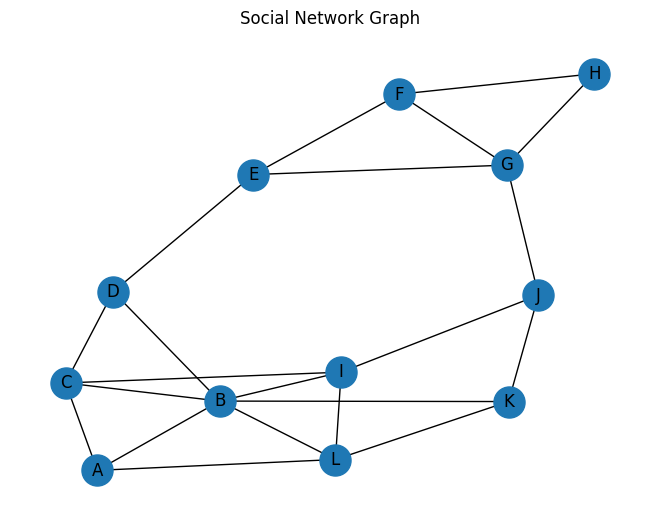

In [5]:
# Step 5: Visualize graph
plt.figure()
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_size=500)
plt.title('Social Network Graph')
plt.show()

In [6]:
# Step 6: Community detection
communities = community.greedy_modularity_communities(G)
for i,c in enumerate(communities):
    print(f'Community {i+1}:', sorted(c))

Community 1: ['A', 'B', 'C', 'D', 'I', 'L']
Community 2: ['E', 'F', 'G', 'H']
Community 3: ['J', 'K']


In [7]:
# Step 7: Degree centrality
deg = nx.degree_centrality(G)
sorted_deg = sorted(deg.items(), key=lambda x:x[1], reverse=True)
print('Top influencer:', sorted_deg[0])

Top influencer: ('B', 0.5454545454545454)


In [8]:
# Step 8: Betweenness centrality
bet = nx.betweenness_centrality(G)
sorted_bet = sorted(bet.items(), key=lambda x:x[1], reverse=True)
print('Top bridge:', sorted_bet[0])

Top bridge: ('J', 0.23823953823953822)


In [9]:
# Step 9: Eigenvector centrality
eig = nx.eigenvector_centrality(G, max_iter=1000)
sorted_eig = sorted(eig.items(), key=lambda x:x[1], reverse=True)
print('Top influence (eigen):', sorted_eig[0])

Top influence (eigen): ('B', 0.5093280196078077)


In [10]:
# Step 10: Insights
print('Communities show user clusters.')
print('Top influencer has highest connections.')
print('Bridge node connects communities.')

Communities show user clusters.
Top influencer has highest connections.
Bridge node connects communities.
